# 02 - Does a real model move the way the bound predicts?

`01_bound.ipynb` computed what is achievable. Exclusive queues (`gpu`,
`gpu_titanrtx`) have co-tenancy multiplicity `k = 1` for every window, so their
Bayes-optimal average precision is exactly **1.000**. Shared queues bound out at
**0.867** on test. That is a clean natural experiment sitting inside one cluster:
two populations, same hardware, same telemetry, same pipeline, different label
ambiguity.

## Pre-registration

Fixed before the models below were fitted.

**P1.** A single model trained on all queues will score higher average precision on
the exclusive test population than on the shared test population.

**P2 (the quantitative one).** The ratio will be close to the ratio of the bounds,
`1.000 / 0.867 = 1.153`. A much larger ratio means something other than co-tenancy
also differs between queues; a ratio near 1.0 means the bound does not bite in
practice at the performance level these models reach.

**P3.** Training on exclusive queues alone will *not* beat the all-queue model on
the exclusive test set, because the exclusive training set is ~12x smaller. Any
comparison of separately trained models must therefore be size-matched.

## Fixed protocol

Chosen in advance, applied identically to every arm, and not tuned:

* features: the 56 columns from `eda/data/windows.parquet` (14 metrics x min/max/mean/std)
* model: LightGBM, `learning_rate=0.05`, `num_leaves=31`, **300 rounds, no early stopping**
* split: the temporal 80/20 split already stored in the file
* metric: average precision; *lift* = AP / (test positive rate); *attainment* = AP / bound
* uncertainty: 200 bootstrap resamples **over test jobs**, not over windows

Session 3 found that early stopping on a temporally adjacent holdout silently
truncated the round budget and cost 27 % of PR-AUC. A fixed budget is used here
for exactly that reason.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

EXCLUSIVE_QUEUES = ("gpu", "gpu_titanrtx")
PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, n_jobs=-1, random_state=0)
N_BOOT   = 200
N_MATCH  = 10          # size-matched shared subsamples
RNG      = np.random.default_rng(0)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print("setup ok")

setup ok


## Step 1 - Load the windows and the bound

The windows come from `eda/02_windows.ipynb` (stride 10). The bound comes from
`01_bound.ipynb`, computed on *every* potential window rather than the strided
sample, because the bound is a property of the measurement.

In [2]:
w = pd.read_parquet(EDA / "windows.parquet")
FEATURES = [c for c in w.columns if "__" in c]
w["klass"] = np.where(w.nodetypes.astype(str).isin(EXCLUSIVE_QUEUES), "exclusive", "shared")

bound = pd.read_csv(DATA / "bayes_bound.csv")
BOUND = {r.arm: r.bayes_ap for _, r in bound[bound.split == "test"].iterrows()}

tr = w[w.split == "train"]
te = w[w.split == "test"]
print(f"windows {len(w):,}   features {len(FEATURES)}   "
      f"train {len(tr):,}   test {len(te):,}")
print()
print(w.groupby(["klass", "split"]).agg(
        windows=("y", "size"), positives=("y", "sum"),
        jobs=("slurm_id", "nunique")).to_string())
print()
print("test-set Bayes bounds:", {k: round(v, 4) for k, v in BOUND.items()})

windows 1,057,817   features 56   train 915,508   test 142,309

                 windows  positives  jobs
klass     split                          
exclusive test     28988        899   777
          train    71147       2192   399
shared    test    113321       4927  1917
          train   844361      27647  9866

test-set Bayes bounds: {'all': 0.9023, 'exclusive': 1.0, 'shared': 0.8675}


## Step 2 - Helper functions

`evaluate` scores one model on one evaluation population and returns average
precision together with a bootstrap interval resampled over **jobs**. Resampling
windows instead would be wrong twice over: windows inside a job are serially
correlated, and co-resident jobs share feature rows outright, so neither windows nor
jobs are fully independent. Clustering on jobs handles the first and is the
convention used in session 3; the residual co-tenancy dependence is noted in the
limitations at the end.

In [3]:
def ap_ci(y, score, groups, n_boot=N_BOOT, rng=None):
    """Average precision with a cluster-bootstrap CI over `groups` (job ids)."""
    rng = rng or np.random.default_rng(0)
    ap = average_precision_score(y, score)
    uniq, inv = np.unique(groups, return_inverse=True)
    order = np.argsort(inv, kind='stable')          # group rows once, not per draw
    bounds = np.r_[0, np.cumsum(np.bincount(inv, minlength=len(uniq)))]
    idx_by_group = [order[bounds[g]:bounds[g + 1]] for g in range(len(uniq))]
    boots = np.empty(n_boot)
    for b in range(n_boot):
        pick = rng.integers(0, len(uniq), len(uniq))
        rows = np.concatenate([idx_by_group[g] for g in pick])
        yb = y[rows]
        boots[b] = average_precision_score(yb, score[rows]) if yb.sum() > 0 else np.nan
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return ap, lo, hi, boots

def fit(train_df):
    return lgb.LGBMClassifier(**PARAMS).fit(train_df[FEATURES], train_df.y)

def score_on(model, eval_df):
    return model.predict_proba(eval_df[FEATURES])[:, 1]

print("helpers defined")

helpers defined


## Step 3 - Arm E, the primary test

One model, trained once on every queue, then evaluated separately on the exclusive
and shared test populations. Because it is the *same* model with the *same*
training data, nothing about training size, hyper-parameters or feature set can
differ between the two numbers. The only thing that changes is the population being
scored - which is exactly the variable under test.

In [4]:
model_all = fit(tr)
print(f"model trained on all queues   [{time.time()-t0:.0f}s]")

results = []
boots_E = {}
for name in ["all", "exclusive", "shared"]:
    sub = te if name == "all" else te[te.klass == name]
    y   = sub.y.to_numpy()
    sc  = score_on(model_all, sub)
    ap, lo, hi, bt = ap_ci(y, sc, sub.slurm_id.to_numpy(),
                           rng=np.random.default_rng(1))
    boots_E[name] = bt
    base = y.mean()
    results.append(dict(arm="E: train all", eval_on=name, n=len(sub), pos=int(y.sum()),
                        base=base, ap=ap, lo=lo, hi=hi, lift=ap / base,
                        bound=BOUND[name], attain=ap / BOUND[name]))

E = pd.DataFrame(results)
print()
print(E.round(4).to_string(index=False))

model trained on all queues   [12s]



         arm   eval_on      n  pos   base     ap     lo     hi   lift  bound  attain
E: train all       all 142309 5826 0.0409 0.0797 0.0606 0.1289 1.9471 0.9023  0.0883
E: train all exclusive  28988  899 0.0310 0.0971 0.0594 0.1851 3.1299 1.0000  0.0971
E: train all    shared 113321 4927 0.0435 0.0808 0.0629 0.1402 1.8584 0.8675  0.0931


### The pre-registered contrast

`P2` predicted a ratio near 1.153. The interval below comes from resampling jobs in
each population independently, 200 times, and taking the ratio each time.

In [5]:
r_ex = boots_E["exclusive"]
r_sh = boots_E["shared"]
ratio_boot = r_ex / r_sh
ap_ex = E[E.eval_on == "exclusive"].ap.iloc[0]
ap_sh = E[E.eval_on == "shared"].ap.iloc[0]
ratio = ap_ex / ap_sh
r_lo, r_hi = np.nanpercentile(ratio_boot, [2.5, 97.5])
predicted = BOUND["exclusive"] / BOUND["shared"]

facts["arm_E_ap_exclusive"] = float(ap_ex)
facts["arm_E_ap_shared"]    = float(ap_sh)
facts["arm_E_ratio"]        = float(ratio)
facts["arm_E_ratio_ci"]     = [float(r_lo), float(r_hi)]
facts["predicted_ratio"]    = float(predicted)

print(f"measured AP ratio  exclusive / shared : {ratio:.3f}  95 % CI [{r_lo:.3f}, {r_hi:.3f}]")
print(f"predicted by the bound alone          : {predicted:.3f}")
print()
print(f"P1  exclusive scores higher : "
      f"{'CONFIRMED' if r_lo > 1.0 else 'NOT RESOLVED (CI includes 1.0)'}")

# P2 is only meaningful if the interval is narrow enough to have excluded something.
# With 48 positive jobs on the exclusive side it may not be, so we say so explicitly
# instead of claiming a confirmation the data cannot support.
consistent   = r_lo <= predicted <= r_hi
discriminating = not (r_lo <= 1.0 <= r_hi)
print(f"P2  ratio consistent with the bound : "
      f"{'yes' if consistent else 'NO - the gap exceeds what co-tenancy explains'}")
print(f"    ...but is the test discriminating? {'yes' if discriminating else 'NO'}")
if not discriminating:
    print(f"    The 95 % CI [{r_lo:.3f}, {r_hi:.3f}] also contains 1.0 (no effect), so it")
    print(f"    would have accepted the bound's prediction whether or not it were true.")
    print(f"    P2 is therefore NOT EVIDENCE. Report the point estimate and the width.")
facts["arm_E_test_discriminating"] = bool(discriminating)

print()
print("The comparison that does survive the small sample - attainment, i.e. the")
print("fraction of each population's own ceiling that the same model collects:")
for _, r in E[E.eval_on != "all"].iterrows():
    print(f"    {r.eval_on:10s} AP {r.ap:.4f} / ceiling {r.bound:.4f} = {r.attain:.4f}")
print("Near-equal attainment is what the bound predicts: the populations differ in")
print("how much is achievable, not in how hard it is to approach what is achievable.")

measured AP ratio  exclusive / shared : 1.201  95 % CI [0.510, 2.253]
predicted by the bound alone          : 1.153

P1  exclusive scores higher : NOT RESOLVED (CI includes 1.0)
P2  ratio consistent with the bound : yes
    ...but is the test discriminating? NO
    The 95 % CI [0.510, 2.253] also contains 1.0 (no effect), so it
    would have accepted the bound's prediction whether or not it were true.
    P2 is therefore NOT EVIDENCE. Report the point estimate and the width.

The comparison that does survive the small sample - attainment, i.e. the
fraction of each population's own ceiling that the same model collects:
    exclusive  AP 0.0971 / ceiling 1.0000 = 0.0971
    shared     AP 0.0808 / ceiling 0.8675 = 0.0931
Near-equal attainment is what the bound predicts: the populations differ in
how much is achievable, not in how hard it is to approach what is achievable.


## Step 4 - Arms B, C and D, separately trained models

Arm E holds training constant and varies the evaluation population. These arms do
the opposite: they train on one population and evaluate on it, which is what a
practitioner would actually do if they decided to run the pipeline on exclusive
queues only.

* **B** trains on exclusive only (399 jobs, ~71 k windows)
* **C** trains on shared only (9 866 jobs, ~844 k windows)
* **D** trains on shared, subsampled by job to match B's training size, repeated
  `N_MATCH` times - the control that makes B and C comparable at all

In [6]:
tr_ex, tr_sh = tr[tr.klass == "exclusive"], tr[tr.klass == "shared"]
te_ex, te_sh = te[te.klass == "exclusive"], te[te.klass == "shared"]
target_windows = len(tr_ex)

rows = []
for tag, train_df, eval_df, ev in [("B: train exclusive", tr_ex, te_ex, "exclusive"),
                                   ("C: train shared",    tr_sh, te_sh, "shared")]:
    m  = fit(train_df)
    y  = eval_df.y.to_numpy()
    sc = score_on(m, eval_df)
    ap, lo, hi, _ = ap_ci(y, sc, eval_df.slurm_id.to_numpy(), rng=np.random.default_rng(2))
    rows.append(dict(arm=tag, eval_on=ev, n_train=len(train_df), n=len(eval_df),
                     pos=int(y.sum()), base=y.mean(), ap=ap, lo=lo, hi=hi,
                     lift=ap / y.mean(), bound=BOUND[ev], attain=ap / BOUND[ev]))
    print(f"{tag:22s} trained on {len(train_df):>7,} windows   [{time.time()-t0:.0f}s]")

# Arm D: shared training data cut down to the exclusive arm's size, by job.
# Jobs are shuffled and taken until the window budget is met, so the subsample is a
# random set of whole jobs -- never a random set of windows, which would leak a job
# across the sample boundary.
wc = tr_sh.groupby("slurm_id", observed=True).size()          # windows per shared job
sh_jobs = wc.index.to_numpy()
d_aps, d_jobs = [], []
for rep in range(N_MATCH):
    rng  = np.random.default_rng(100 + rep)
    perm = rng.permutation(len(sh_jobs))
    cum  = wc.to_numpy()[perm].cumsum()
    n_take = int(np.searchsorted(cum, target_windows) + 1)
    take = sh_jobs[perm[:n_take]]
    sub_tr = tr_sh[tr_sh.slurm_id.isin(take)]
    m  = fit(sub_tr)
    sc = score_on(m, te_sh)
    d_aps.append(average_precision_score(te_sh.y.to_numpy(), sc))
    d_jobs.append(n_take)
    print(f"  D rep {rep+1:2d}: {len(sub_tr):>7,} windows, {n_take:>4,} jobs "
          f"-> AP {d_aps[-1]:.4f}   [{time.time()-t0:.0f}s]")

d_aps = np.array(d_aps)
rows.append(dict(arm="D: train shared (size-matched)", eval_on="shared",
                 n_train=target_windows, n=len(te_sh), pos=int(te_sh.y.sum()),
                 base=te_sh.y.mean(), ap=d_aps.mean(), lo=d_aps.min(), hi=d_aps.max(),
                 lift=d_aps.mean() / te_sh.y.mean(), bound=BOUND["shared"],
                 attain=d_aps.mean() / BOUND["shared"]))
BCD = pd.DataFrame(rows)
print()
print(BCD.round(4).to_string(index=False))

B: train exclusive     trained on  71,147 windows   [25s]


C: train shared        trained on 844,361 windows   [38s]


  D rep  1:  71,380 windows,  796 jobs -> AP 0.0686   [40s]


  D rep  2:  71,154 windows,  856 jobs -> AP 0.0777   [42s]


  D rep  3:  71,260 windows,  845 jobs -> AP 0.0725   [44s]


...

  D rep  6:  71,213 windows,  781 jobs -> AP 0.0566   [50s]


  D rep  7:  72,526 windows,  891 jobs -> AP 0.0808   [52s]


  D rep  8:  71,534 windows,  888 jobs -> AP 0.0924   [54s]


  D rep  9:  71,412 windows,  799 jobs -> AP 0.0636   [56s]


  D rep 10:  71,199 windows,  825 jobs -> AP 0.0860   [58s]

                           arm   eval_on  n_train      n  pos   base     ap     lo     hi   lift  bound  attain
            B: train exclusive exclusive    71147  28988  899 0.0310 0.0589 0.0378 0.1067 1.8990 1.0000  0.0589
               C: train shared    shared   844361 113321 4927 0.0435 0.0867 0.0662 0.1291 1.9948 0.8675  0.1000
D: train shared (size-matched)    shared    71147 113321 4927 0.0435 0.0758 0.0566 0.0924 1.7424 0.8675  0.0873


### B versus D - the size-matched comparison

This is the comparison a practitioner cares about: given a fixed training budget, is
it better to train on clean exclusive-queue labels or on ambiguous shared-queue ones?

In [7]:
ap_B = BCD[BCD.arm.str.startswith("B")].ap.iloc[0]
ap_D = BCD[BCD.arm.str.startswith("D")].ap.iloc[0]
ap_C = BCD[BCD.arm.str.startswith("C")].ap.iloc[0]

facts["arm_B_ap"] = float(ap_B)
facts["arm_C_ap"] = float(ap_C)
facts["arm_D_ap_mean"] = float(d_aps.mean())
facts["arm_D_ap_range"] = [float(d_aps.min()), float(d_aps.max())]

print(f"B  exclusive train -> exclusive test      AP {ap_B:.4f}")
print(f"D  shared train (size-matched) -> shared  AP {ap_D:.4f}  "
      f"range [{d_aps.min():.4f}, {d_aps.max():.4f}] over {N_MATCH} draws")
print(f"C  shared train (full)  -> shared test    AP {ap_C:.4f}")
print()
print(f"B / D = {ap_B/ap_D:.3f}   (bound predicts {BOUND['exclusive']/BOUND['shared']:.3f})")
print(f"C / D = {ap_C/ap_D:.3f}   <- pure training-size effect on the same population")
print()
print(f"P3  more data beats cleaner labels : "
      f"{'CONFIRMED' if ap_C > ap_B else 'REJECTED'}")

B  exclusive train -> exclusive test      AP 0.0589
D  shared train (size-matched) -> shared  AP 0.0758  range [0.0566, 0.0924] over 10 draws
C  shared train (full)  -> shared test    AP 0.0867

B / D = 0.777   (bound predicts 1.153)
C / D = 1.145   <- pure training-size effect on the same population

P3  more data beats cleaner labels : CONFIRMED


## Step 5 - Attainment: how much of each ceiling is actually reached

Raw average precision is not comparable across populations, because they have
different positive rates *and* different ceilings. Dividing by the ceiling puts both
on one scale: what fraction of the achievable average precision does the model
actually collect?

In [8]:
att = pd.concat([E.assign(source="E"), BCD.assign(source="BCD")], ignore_index=True)
show = att[["arm", "eval_on", "n", "pos", "base", "ap", "bound", "attain", "lift"]]
print(show.round(4).to_string(index=False))
facts["attainment_exclusive_armE"] = float(E[E.eval_on == "exclusive"].attain.iloc[0])
facts["attainment_shared_armE"]    = float(E[E.eval_on == "shared"].attain.iloc[0])
att.to_csv(DATA / "arms.csv", index=False)

                           arm   eval_on      n  pos   base     ap  bound  attain   lift
                  E: train all       all 142309 5826 0.0409 0.0797 0.9023  0.0883 1.9471
                  E: train all exclusive  28988  899 0.0310 0.0971 1.0000  0.0971 3.1299
                  E: train all    shared 113321 4927 0.0435 0.0808 0.8675  0.0931 1.8584
            B: train exclusive exclusive  28988  899 0.0310 0.0589 1.0000  0.0589 1.8990
               C: train shared    shared 113321 4927 0.0435 0.0867 0.8675  0.1000 1.9948
D: train shared (size-matched)    shared 113321 4927 0.0435 0.0758 0.8675  0.0873 1.7424


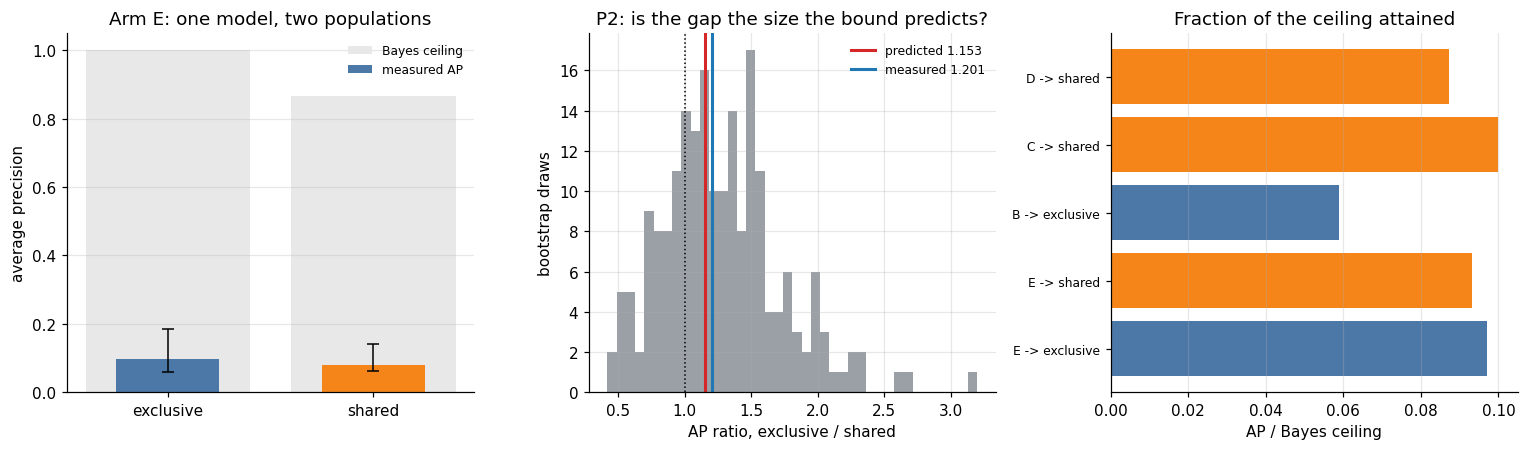

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) measured AP with CIs, against each population's ceiling
sub = E[E.eval_on != "all"]
x = np.arange(len(sub))
ax[0].bar(x, sub.bound, color="#e8e8e8", label="Bayes ceiling")
ax[0].bar(x, sub.ap, color=["#4c78a8", "#f58518"], width=.5, label="measured AP")
ax[0].errorbar(x, sub.ap, yerr=[sub.ap - sub.lo, sub.hi - sub.ap],
               fmt="none", ecolor="k", capsize=4, lw=1)
ax[0].set_xticks(x, sub["eval_on"]); ax[0].set_ylabel("average precision")
ax[0].set_title("Arm E: one model, two populations")
ax[0].legend(frameon=False, fontsize=8); ax[0].grid(axis="x", visible=False)

# (b) the ratio against the prediction
ax[1].hist(ratio_boot, bins=40, color="#9aa0a6")
ax[1].axvline(predicted, color="#d62728", lw=2, label=f"predicted {predicted:.3f}")
ax[1].axvline(ratio, color="#1f77b4", lw=2, label=f"measured {ratio:.3f}")
ax[1].axvline(1.0, color="k", ls=":", lw=1)
ax[1].set(xlabel="AP ratio, exclusive / shared", ylabel="bootstrap draws",
          title="P2: is the gap the size the bound predicts?")
ax[1].legend(frameon=False, fontsize=8)

# (c) attainment
a = att.dropna(subset=["attain"])
a = a[a["eval_on"] != "all"]
ax[2].barh(range(len(a)), a.attain, color=["#4c78a8" if e == "exclusive" else "#f58518"
                                           for e in a["eval_on"]])
ax[2].set_yticks(range(len(a)), [f"{r.arm.split(':')[0]} -> {r['eval_on']}" for _, r in a.iterrows()],
                 fontsize=8)
ax[2].set(xlabel="AP / Bayes ceiling", title="Fraction of the ceiling attained")
ax[2].grid(axis="y", visible=False)

plt.tight_layout(); save(fig, "02_experiment.png"); plt.show()

## Step 6 - Robustness: drop the degenerate queue

`gpu_shared_jupyter` is 99.95 % positive - essentially every window in it is inside
a failure horizon. A queue that is almost entirely one class can move an aggregate
metric on its own, so the primary contrast is recomputed without it.

In [10]:
te_nj = te[te.nodetypes.astype(str) != "gpu_shared_jupyter"]
out = []
for name in ["exclusive", "shared"]:
    sub = te_nj[te_nj.klass == name]
    y, sc = sub.y.to_numpy(), score_on(model_all, sub)
    out.append((name, len(sub), int(y.sum()), y.mean(), average_precision_score(y, sc)))
rob = pd.DataFrame(out, columns=["eval_on", "n", "pos", "base", "ap"])
print(rob.round(4).to_string(index=False))
ratio_nj = rob[rob.eval_on == "exclusive"].ap.iloc[0] / rob[rob.eval_on == "shared"].ap.iloc[0]
facts["ratio_without_jupyter"] = float(ratio_nj)
print()
print(f"AP ratio without gpu_shared_jupyter : {ratio_nj:.3f}  "
      f"(with it: {ratio:.3f})")

  eval_on      n  pos   base     ap
exclusive  28988  899 0.0310 0.0971
   shared 113204 4810 0.0425 0.0774

AP ratio without gpu_shared_jupyter : 1.253  (with it: 1.201)


## Step 7 - Verdict and limitations

In [11]:
json.dump(facts, open(DATA / "facts_experiment.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:32s} {v}")
print()
print(f"[{time.time()-t0:.0f}s total]")

arm_E_ap_exclusive               0.09706620280890722
arm_E_ap_shared                  0.08080094451737961
arm_E_ratio                      1.201300348512994
arm_E_ratio_ci                   [0.510287702762696, 2.2532351986597967]
predicted_ratio                  1.152786800247983
arm_E_test_discriminating        False
arm_B_ap                         0.05889357586452504
arm_C_ap                         0.08673199684701337
arm_D_ap_mean                    0.07575449529947112
arm_D_ap_range                   [0.056571718959429716, 0.09236838035820749]
attainment_exclusive_armE        0.09706620280890722
attainment_shared_armE           0.09314626228720485
ratio_without_jupyter            1.2534051291062291

[59s total]


### Limitations, stated rather than buried

1. **The exclusive test set is small.** 777 jobs, of which only 48 are failing jobs
   that produce a positive window. Every interval on that side is wide, and it is the
   reason `P1` is reported with its interval rather than as a bare comparison.

2. **This is a natural experiment, not a randomised one.** Exclusive and shared
   queues differ in more than co-tenancy - job length, workload type and user
   population all vary with the queue. The bound tells us how much of the gap
   co-tenancy *should* explain; anything beyond that is confounded and cannot be
   attributed.

3. **The exclusive training set contains no NODE_FAIL positives at all**, while its
   test set contains 66. Arm B is therefore asked to detect a failure mode it never
   saw, which handicaps it for a reason unrelated to co-tenancy.

4. **Bootstrap clusters are jobs, but co-resident jobs are not independent** - they
   share feature rows outright. The intervals here are therefore slightly optimistic,
   in the same way session 3's were.

5. **Arm D is matched on windows, not on jobs.** Exclusive jobs are longer, so
   matching the window budget gives arm B ~399 training jobs against arm D's ~830.
   B therefore sees fewer independent jobs as well as cleaner labels, and `B / D`
   below 1 cannot be attributed to label quality alone.

6. **The primary test is underpowered and says so.** With 48 positive jobs on the
   exclusive side the bootstrap interval on the ratio spans roughly [0.5, 2.3]. The
   point estimate lands close to the prediction, but an interval that wide would have
   accepted almost any prediction. This is reported as an unresolved test rather than
   a confirmation, which is what pre-registration is for.

7. **The feature set is the 56-column `eda/` set, not the 144-column set** that
   produced the 3.12x headline in `pipeline_v2`. Absolute numbers here are lower by
   construction and are not comparable to that figure. Every arm uses the same 56
   columns, so the *contrasts* are valid; the *levels* are not.